# 日経平均株価 15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf

from funcs.commons import get_name_15min_chart, get_name_15min_chart_usd

In [3]:
code = "N225"
symbol = f"^{code}"
yticker = yf.Ticker(symbol)
df = yticker.history(period="1d", interval="15m")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-02 09:00:00+09:00,54066.828125,54258.480469,53984.679688,53994.289062,0,0.0,0.0
2026-04-02 09:15:00+09:00,54019.109375,54170.339844,53956.871094,53996.531250,0,0.0,0.0
2026-04-02 09:30:00+09:00,53972.320312,54212.429688,53923.789062,54203.230469,0,0.0,0.0
2026-04-02 09:45:00+09:00,54206.359375,54215.851562,54034.328125,54170.828125,0,0.0,0.0
2026-04-02 10:00:00+09:00,54162.531250,54190.570312,53656.230469,53901.621094,0,0.0,0.0
2026-04-02 10:15:00+09:00,53895.421875,53901.570312,53214.121094,53332.398438,0,0.0,0.0
2026-04-02 10:30:00+09:00,53254.269531,53295.968750,52967.230469,53029.859375,0,0.0,0.0
2026-04-02 10:45:00+09:00,53028.398438,53056.601562,52810.878906,52975.968750,0,0.0,0.0
2026-04-02 11:00:00+09:00,52991.660156,53118.050781,52717.410156,52734.480469,0,0.0,0.0


In [4]:
dt_start = df.index[0]
dt_end = pd.to_datetime(
    f"{dt_start.year:04d}-{dt_start.month:02d}-{dt_start.day:02d} 15:30:00+09:00"
).tz_convert("Asia/Tokyo")
dt_start, dt_end

(Timestamp('2026-04-02 09:00:00+0900', tz='Asia/Tokyo'),
 Timestamp('2026-04-02 15:30:00+0900', tz='Asia/Tokyo'))

In [5]:
# 過去一週間のデータを取得
td = datetime.timedelta(days=7)
dt_first = df.index[0]
dt_prev = dt_first - td
df_last = yticker.history(interval="1d", start=str(dt_prev.date()))
print(df_last["Close"])
n = len(df_last)
lastclose = df_last[n - 2 : n - 1]["Close"].iloc[0]
# lastclose = 50168.11 # 12/15 終値
# 確認のため出力
df_last[n - 2 : n - 1]["Close"]

Date
2026-03-26 00:00:00+09:00    53603.648438
2026-03-27 00:00:00+09:00    53373.070312
2026-03-30 00:00:00+09:00    51885.851562
2026-03-31 00:00:00+09:00    51063.718750
2026-04-01 00:00:00+09:00    53739.679688
2026-04-02 00:00:00+09:00    52796.910156
Name: Close, dtype: float64


Date
2026-04-01 00:00:00+09:00    53739.679688
Name: Close, dtype: float64

In [6]:
delta_open = df.head(1)["Open"].iloc[0] - lastclose
print(f"{delta_open:+.2f}")

+327.15


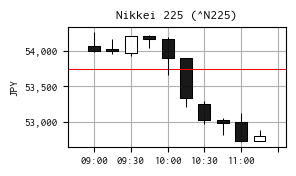

In [7]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose, color="red", linewidth=0.75)
mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("JPY")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol})")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol})")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart(code, dt_first))
plt.show()

In [8]:
code2 = "USDJPY=X"
symbol2 = code2
ticker2 = yf.Ticker(symbol2)

In [9]:
# 15分足で過去 2 日分のデータを取得
df_exchange = ticker2.history(period="2d", interval="15m")
df_exchange.index = df_exchange.index.tz_convert("Asia/Tokyo")
df_exchange

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-01 08:00:00+09:00,158.723999,158.778000,158.688995,158.723999,0,0.0,0.0
2026-04-01 08:15:00+09:00,158.718002,158.727005,158.550995,158.589005,0,0.0,0.0
2026-04-01 08:30:00+09:00,158.587997,158.641998,158.578003,158.604996,0,0.0,0.0
2026-04-01 08:45:00+09:00,158.600998,158.654007,158.563004,158.585999,0,0.0,0.0
2026-04-01 09:00:00+09:00,158.587006,158.623001,158.542007,158.569000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-02 10:30:00+09:00,159.067993,159.212006,159.054993,159.188995,0,0.0,0.0
2026-04-02 10:45:00+09:00,159.179993,159.285995,159.147995,159.274994,0,0.0,0.0
2026-04-02 11:00:00+09:00,159.281006,159.302002,159.186996,159.192993,0,0.0,0.0


In [10]:
ser_rate = df_exchange.loc[df.index, "Close"]
ser_rate
df2 = pd.DataFrame()
df2["Open"] = df["Open"] / ser_rate
df2["High"] = df["High"] / ser_rate
df2["Low"] = df["Low"] / ser_rate
df2["Close"] = df["Close"] / ser_rate
df2

,Open,High,Low,Close
Datetime,,,,
2026-04-02 09:00:00+09:00,340.584894,341.792176,340.067414,340.127946
2026-04-02 09:15:00+09:00,340.397931,341.350900,340.005741,340.255657
2026-04-02 09:30:00+09:00,340.197431,341.710884,339.891529,341.652900
2026-04-02 09:45:00+09:00,341.640322,341.700147,340.556080,341.416383
2026-04-02 10:00:00+09:00,341.297396,341.474080,338.107014,339.653308
2026-04-02 10:15:00+09:00,338.817883,338.856535,334.534831,335.278391
2026-04-02 10:30:00+09:00,334.534868,334.796816,332.731734,333.125159
2026-04-02 10:45:00+09:00,332.936120,333.113192,331.570434,332.606943
2026-04-02 11:00:00+09:00,332.876838,333.670784,331.154086,331.261316


In [11]:
dt = df_exchange.head(1).index[0]
dt_last_close = pd.to_datetime(f"{str(dt.date())} 15:15:00+09:00")
print(dt_last_close)
last_close_usd = df_exchange.loc[dt_last_close, "Close"]
last_close_usd

2026-04-01 15:15:00+09:00


np.float64(158.4290008544922)

前日終値（ドル換算） 339.20355110272243


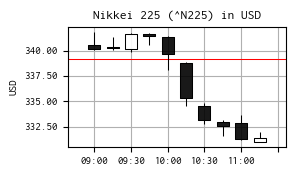

In [12]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose / last_close_usd, color="red", linewidth=0.75)
print("前日終値（ドル換算）", lastclose / last_close_usd)
mpf.plot(
    df2,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
ax.set_ylabel("USD")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol}) in USD")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol}) in USD")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart_usd(code, dt_first))
plt.show()